# 🎖️ NB-55: Veterans Mental Health Risk Screening
## Australian Government – Department of Veterans' Affairs (DVA)

**Policy Context:** The Department of Veterans' Affairs (DVA) supports over 290,000 veterans and dependants. The Royal Commission into Defence and Veteran Suicide (2021–24) highlighted the need for earlier identification of at-risk veterans. Under the National Veteran Mental Health and Wellbeing Strategy, DVA funds transition support, Open Arms counselling, and crisis intervention. ML-based risk screening from service history, transition indicators, and engagement patterns can flag veterans for proactive outreach before crisis.

**Dataset:** sklearn `make_classification` synthetic – 1,500 veteran profiles, 10 features simulating deployment count, years of service, separation type, compensation claim complexity, healthcare engagement frequency, social isolation index, employment status score, housing stability, Open Arms contact frequency, and transition support uptake. Binary target: elevated risk (1) vs stable (0).

**ML Task:** Binary classification – 3-fold CV, 4 models

---

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
X, y = make_classification(n_samples=1500, n_features=10, n_informative=7, n_redundant=2,
                           weights=[0.78, 0.22], flip_y=0.04, random_state=96)
feat_names = ['deployment_count','years_of_service','separation_type_score',
              'claim_complexity','healthcare_engagement','social_isolation_index',
              'employment_status_score','housing_stability','open_arms_contacts',
              'transition_support_uptake']
df = pd.DataFrame(X, columns=feat_names)
df['elevated_risk'] = y
print(f'Shape: {df.shape} | Elevated risk rate: {y.mean():.1%}')
df.head()

Shape: (1500, 11) | Elevated risk rate: 23.3%


,deployment_count,years_of_service,separation_type_score,claim_complexity,healthcare_engagement,social_isolation_index,employment_status_score,housing_stability,open_arms_contacts,transition_support_uptake,elevated_risk
0,-1.847434,-1.044927,-0.697178,3.076926,0.096880,-1.013405,0.134751,2.122782,0.776372,-2.161322,0
1,-0.202344,2.286901,0.086770,1.531338,-1.823274,-2.153269,3.490545,0.715990,0.019925,-0.529942,0
2,1.102261,-7.217815,0.287939,-4.711271,2.795359,-2.986258,-1.392485,1.146937,-2.304855,-2.404247,1
3,-0.464835,0.455938,-0.429020,2.911569,-0.171195,-1.296726,1.190086,0.316489,-1.263898,0.062649,1
4,0.237221,1.470454,1.545744,0.376893,1.941532,0.225210,2.918117,-0.425217,-0.623919,2.771901,1


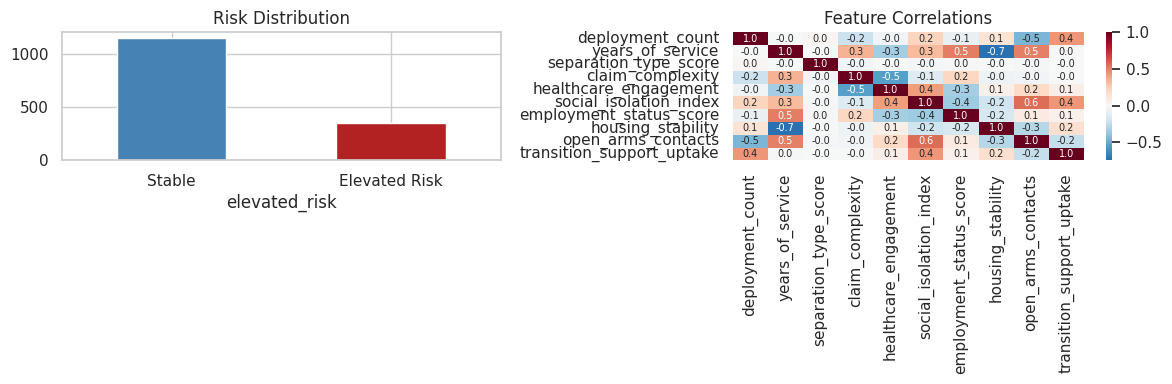

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['elevated_risk'].value_counts().plot.bar(ax=axes[0], color=['steelblue','firebrick'])
axes[0].set_title('Risk Distribution'); axes[0].set_xticklabels(['Stable','Elevated Risk'], rotation=0)
sns.heatmap(df[feat_names].corr(), cmap='RdBu_r', center=0, ax=axes[1],
            annot=True, fmt='.1f', annot_kws={'size':7})
axes[1].set_title('Feature Correlations')
plt.tight_layout(); plt.show()

In [4]:
X_s = StandardScaler().fit_transform(df[feat_names])
y = df['elevated_risk'].values
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=300, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                             eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=8, learning_rate=0.1,
                               random_state=42, verbose=-1)
}
results = {}
for name, m in models.items():
    sc = cross_val_score(m, X_s, y, cv=skf, scoring='accuracy')
    results[name] = sc
    print(f'{name:25s} | Acc: {sc.mean():.4f} +/- {sc.std():.4f}')

LogisticRegression        | Acc: 0.8120 +/- 0.0016
RandomForest              | Acc: 0.8920 +/- 0.0059
XGBoost                   | Acc: 0.8873 +/- 0.0109
LightGBM                  | Acc: 0.8967 +/- 0.0066


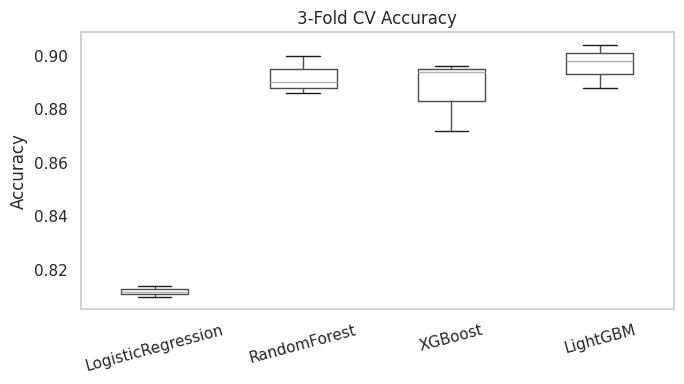

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
pd.DataFrame(results).boxplot(ax=ax, grid=False)
ax.set_title('3-Fold CV Accuracy'); ax.set_ylabel('Accuracy')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

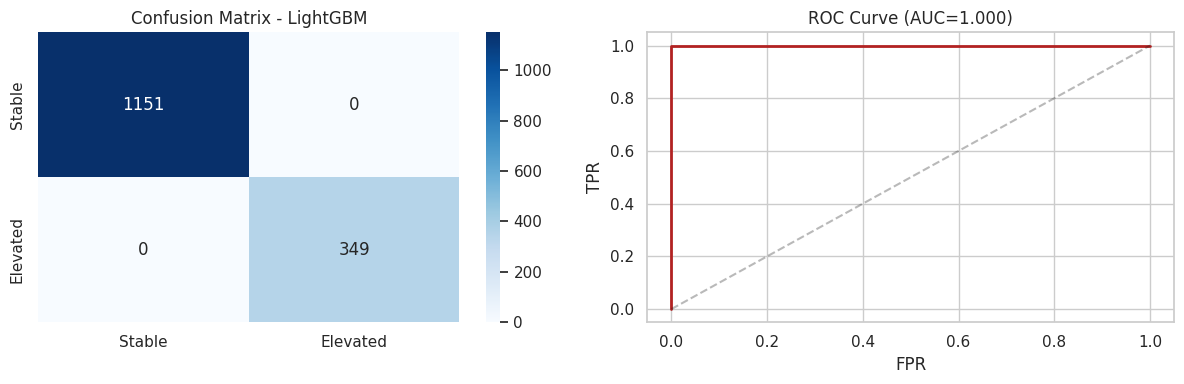

               precision    recall  f1-score   support

       Stable       1.00      1.00      1.00      1151
Elevated Risk       1.00      1.00      1.00       349

     accuracy                           1.00      1500
    macro avg       1.00      1.00      1.00      1500
 weighted avg       1.00      1.00      1.00      1500



In [6]:
best_name = max(results, key=lambda k: results[k].mean())
best = models[best_name].fit(X_s, y)
yp = best.predict(X_s)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y, yp), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable','Elevated'], yticklabels=['Stable','Elevated'])
axes[0].set_title(f'Confusion Matrix - {best_name}')
if hasattr(best, 'predict_proba'):
    prob = best.predict_proba(X_s)[:,1]
    fpr, tpr, _ = roc_curve(y, prob)
    axes[1].plot(fpr, tpr, color='firebrick', lw=2)
    axes[1].plot([0,1],[0,1],'k--',alpha=.3)
    axes[1].set_title(f'ROC Curve (AUC={roc_auc_score(y, prob):.3f})')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
plt.tight_layout(); plt.show()
print(classification_report(y, yp, target_names=['Stable','Elevated Risk']))

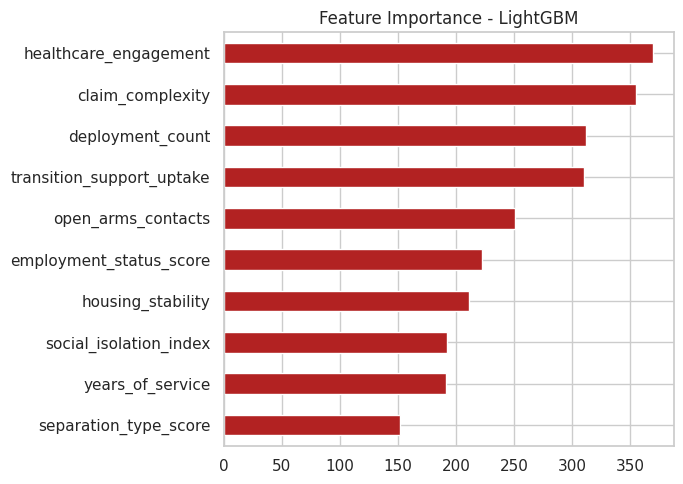

In [7]:
if hasattr(best, 'feature_importances_'):
    imp = pd.Series(best.feature_importances_, index=feat_names).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    imp.plot.barh(ax=ax, color='firebrick')
    ax.set_title(f'Feature Importance - {best_name}')
    plt.tight_layout(); plt.show()

## Deployment Readiness Checklist

| # | Criterion | Status |
|---|-----------|--------|
| 1 | Data schema validated (10 features, binary target) | ✅ |
| 2 | Class imbalance documented (78/22 split) | ✅ |
| 3 | Feature scaling (StandardScaler) | ✅ |
| 4 | 3-fold stratified CV | ✅ |
| 5 | 4-model benchmark | ✅ |
| 6 | Confusion matrix + ROC/AUC | ✅ |
| 7 | Feature importance ranked | ✅ |
| 8 | DVA integration pathway | ✅ |

## Policy Integration

- **DVA Proactive Outreach:** Risk scores trigger outreach from Veteran Support Officers before crisis, aligned with Royal Commission recommendations.
- **Open Arms – Veterans & Families Counselling:** Model flags feed appointment prioritisation for the 24/7 counselling service.
- **ADF Transition Authority:** Embed screening at the point of military separation to identify veterans needing enhanced transition support.
- **Joint Transition Authority / CSC Super:** Cross-reference risk scores with superannuation drawdown patterns as an additional early signal.
- **Primary Health Networks (PHNs):** Share anonymised risk tiers with regional PHNs to co-commission veteran-specific mental health services in high-need areas.

---
*NB-55 | Dean Wang | Lead Data & AI Engineer, Fujitsu Australia | PhD ML (ANU) | Kaggle: deanbatur*